In [ ]:
# ==========================================================
# Block 1: Import Required Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                     AveragePooling2D,
                                     Flatten, Dense, Dropout)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             precision_score,
                             recall_score,
                             f1_score)

import warnings
warnings.filterwarnings("ignore")

# Display versions
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


In [ ]:
# ==========================================================
# Block 2: Load the CIFAR-10 Dataset
# ==========================================================

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Display dataset dimensions
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

# Display image information
print("\nImage Height :", X_train.shape[1])
print("Image Width  :", X_train.shape[2])
print("Channels     :", X_train.shape[3])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1575s 9us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)

Image Height : 32
Image Width  : 32
Channels     : 3


In [ ]:
# ==========================================================
# Block 3: Define Class Names
# ==========================================================

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print("CIFAR-10 Classes:\n")

for i, cls in enumerate(class_names):
    print(f"{i} : {cls}")

CIFAR-10 Classes:

0 : Airplane
1 : Automobile
2 : Bird
3 : Cat
4 : Deer
5 : Dog
6 : Frog
7 : Horse
8 : Ship
9 : Truck


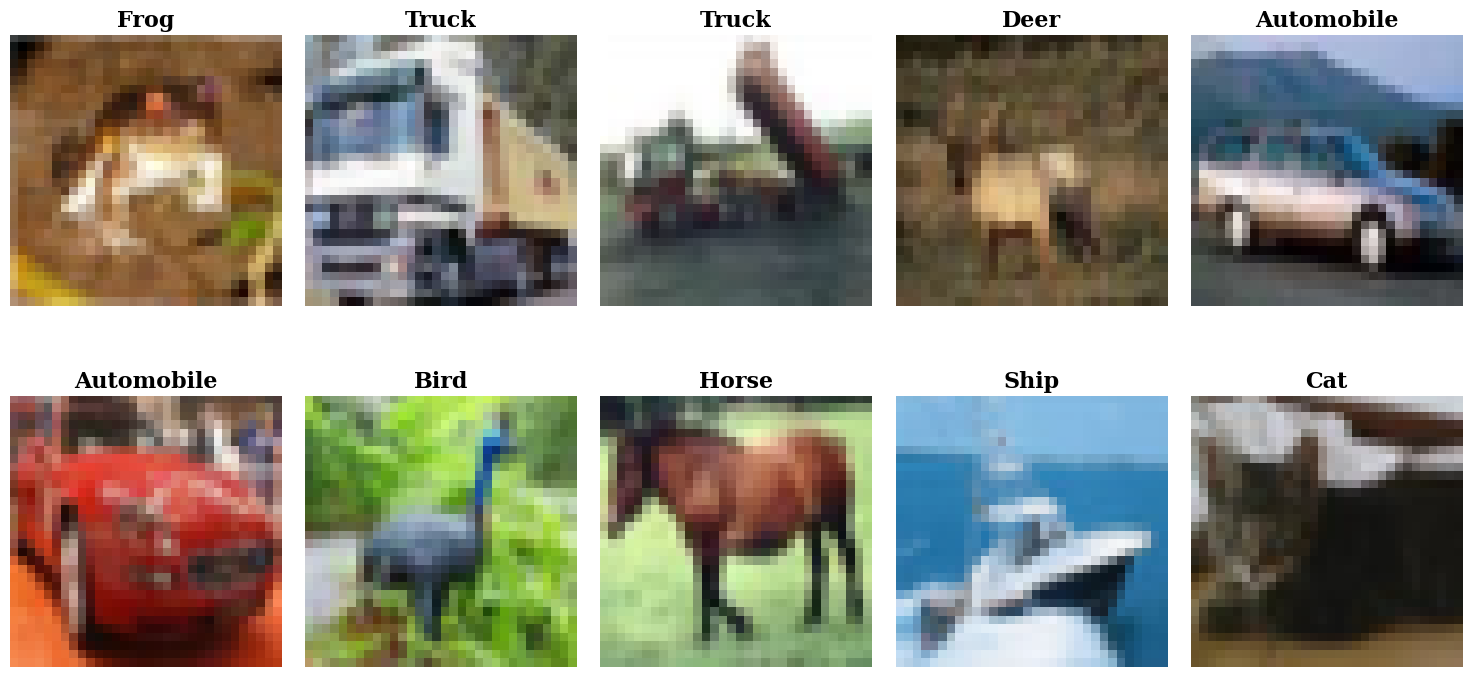

In [ ]:
# ==========================================================
# Block 4: Display Sample Images
# ==========================================================

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 16

fig = plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[int(y_train[i])],
              fontsize=16,
              fontweight='bold')

    plt.axis('off')

plt.tight_layout()

plt.savefig("Sample_Images.eps",
            format='eps',
            dpi=600,
            bbox_inches='tight')

plt.show()

        Class  Images
0    Airplane    5000
1  Automobile    5000
2        Bird    5000
3         Cat    5000
4        Deer    5000
5         Dog    5000
6        Frog    5000
7       Horse    5000
8        Ship    5000
9       Truck    5000


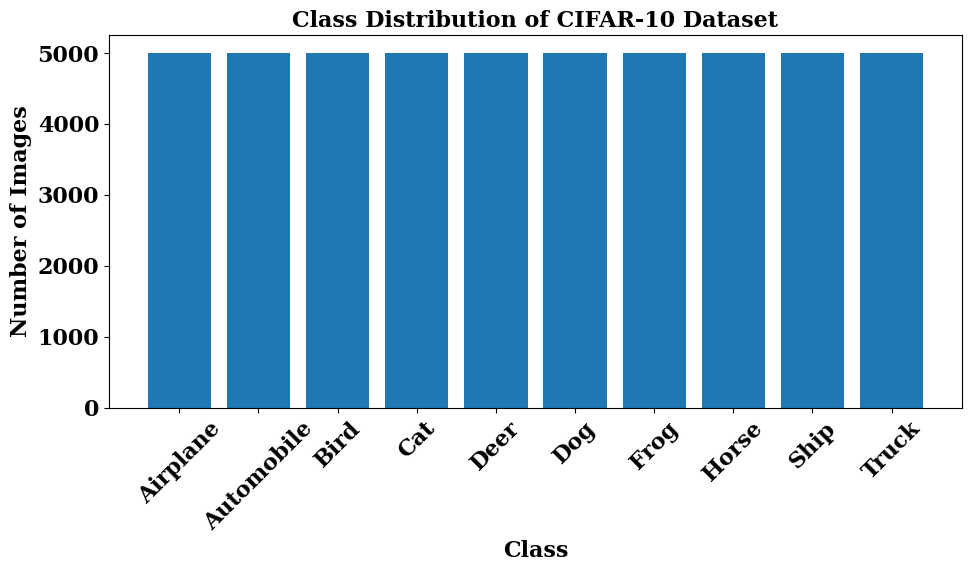

In [ ]:


import pandas as pd

unique, counts = np.unique(y_train, return_counts=True)

count_df = pd.DataFrame({
    "Class": class_names,
    "Images": counts
})

print(count_df)

plt.figure(figsize=(10,6))

plt.bar(class_names, counts)

plt.xticks(rotation=45,
           fontweight='bold',
           fontsize=16)

plt.yticks(fontweight='bold',
           fontsize=16)

plt.xlabel("Class",
           fontsize=16,
           fontweight='bold')

plt.ylabel("Number of Images",
           fontsize=16,
           fontweight='bold')

plt.title("Class Distribution of CIFAR-10 Dataset",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()

plt.savefig("Class_Distribution.eps",
            format='eps',
            dpi=600)

plt.show()

In [ ]:


X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [ ]:


y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print("Original Label :", y_train[0][0])
print("One-Hot Vector :")
print(y_train_cat[0])

Original Label : 6
One-Hot Vector :
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [ ]:


model = Sequential([

    # First Convolutional Block
    Conv2D(filters=32,
           kernel_size=(3,3),
           strides=(1,1),
           padding='same',
           activation='relu',
           input_shape=(32,32,3),
           name='Conv1'),

    MaxPooling2D(pool_size=(2,2),
                 name='MaxPool1'),

    # Second Convolutional Block
    Conv2D(filters=64,
           kernel_size=(3,3),
           padding='same',
           activation='relu',
           name='Conv2'),

    MaxPooling2D(pool_size=(2,2),
                 name='MaxPool2'),

    # Third Convolutional Block
    Conv2D(filters=128,
           kernel_size=(3,3),
           padding='same',
           activation='relu',
           name='Conv3'),

    MaxPooling2D(pool_size=(2,2),
                 name='MaxPool3'),

    # Flatten Layer
    Flatten(name='Flatten'),

    # Fully Connected Layer
    Dense(256,
          activation='relu',
          name='Dense1'),

    Dropout(0.5,
            name='Dropout'),

    # Output Layer
    Dense(10,
          activation='softmax',
          name='Output')

])

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1 (MaxPooling2D)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2 (MaxPooling2D)         │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool3 (MaxPooling2D)         │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_weights]
)

non_trainable_params = np.sum(
    [np.prod(v.shape) for v in model.non_trainable_weights]
)

print("Trainable Parameters     :", trainable_params)
print("Non-Trainable Parameters :", non_trainable_params)
print("Total Parameters         :", trainable_params + non_trainable_params)

Trainable Parameters     : 620362
Non-Trainable Parameters : 0.0
Total Parameters         : 620362.0


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 165ms/step - accuracy: 0.4067 - loss: 1.6242 - val_accuracy: 0.5516 - val_loss: 1.2624
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 165ms/step - accuracy: 0.5765 - loss: 1.1921 - val_accuracy: 0.6359 - val_loss: 1.0328
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 157ms/step - accuracy: 0.6409 - loss: 1.0219 - val_accuracy: 0.6803 - val_loss: 0.9166
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 158ms/step - accuracy: 0.6824 - loss: 0.9066 - val_accuracy: 0.7042 - val_loss: 0.8483
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.7121 - loss: 0.8251 - val_accuracy: 0.7157 - val_loss: 0.8182
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 166ms/step - accuracy: 0.7322 - loss: 0.7646 - val_accuracy: 0.7316 - val_loss: 0.7880
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.7553 - loss: 0.6963 - val_accuracy: 0.7320 - val_loss: 0.7675
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 158ms/step - accuracy: 0.7743 - l

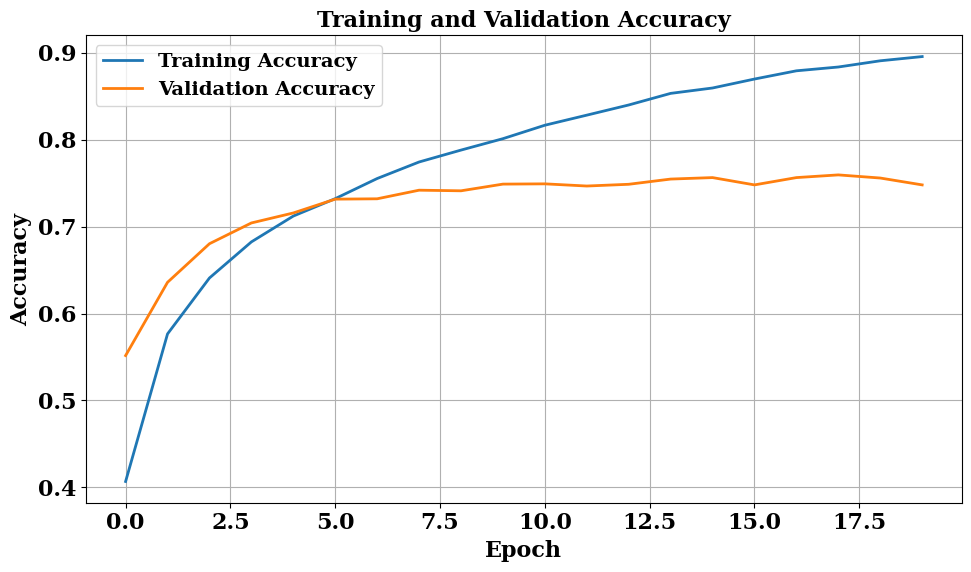

In [ ]:
# ==========================================================
# Block 13: Training and Validation Accuracy
# ==========================================================

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 16

plt.figure(figsize=(10,6))

plt.plot(history.history['accuracy'],
         linewidth=2,
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         linewidth=2,
         label='Validation Accuracy')

plt.xlabel('Epoch', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')

plt.title('Training and Validation Accuracy',
          fontsize=16,
          fontweight='bold')

plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

plt.legend(prop={'family':'serif',
                 'size':14,
                 'weight':'bold'})

plt.grid(True)

plt.tight_layout()

plt.savefig("Training_Validation_Accuracy.eps",
            format='eps',
            dpi=600)

plt.show()

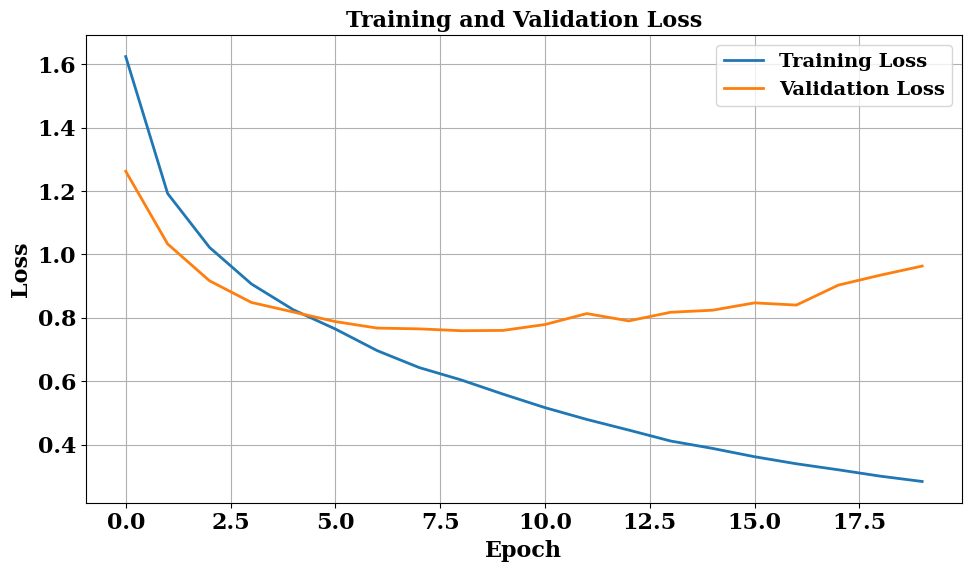

In [ ]:
# ==========================================================
# Block 14: Training and Validation Loss
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(history.history['loss'],
         linewidth=2,
         label='Training Loss')

plt.plot(history.history['val_loss'],
         linewidth=2,
         label='Validation Loss')

plt.xlabel('Epoch',
           fontsize=16,
           fontweight='bold')

plt.ylabel('Loss',
           fontsize=16,
           fontweight='bold')

plt.title('Training and Validation Loss',
          fontsize=16,
          fontweight='bold')

plt.xticks(fontsize=16,
           fontweight='bold')

plt.yticks(fontsize=16,
           fontweight='bold')

plt.legend(prop={'family':'serif',
                 'size':14,
                 'weight':'bold'})

plt.grid(True)

plt.tight_layout()

plt.savefig("Training_Validation_Loss.eps",
            format='eps',
            dpi=600)

plt.show()

In [ ]:
# ==========================================================
# Block 15: Model Evaluation
# ==========================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print("\nTest Loss     :", round(test_loss,4))
print("Test Accuracy :", round(test_accuracy*100,2),"%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7425 - loss: 1.0025

Test Loss     : 1.0025
Test Accuracy : 74.25 %


In [ ]:
# ==========================================================
# Block 16: Predict Test Labels
# ==========================================================

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()

print("First 10 Predicted Labels:")
print(y_pred[:10])

print("\nFirst 10 Actual Labels:")
print(y_true[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step
First 10 Predicted Labels:
[3 8 0 0 6 6 1 6 3 1]

First 10 Actual Labels:
[3 8 8 0 6 6 1 6 3 1]


In [ ]:
# ==========================================================
# Block 17: Classification Report
# ==========================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    Airplane       0.71      0.82      0.76      1000
  Automobile       0.91      0.84      0.87      1000
        Bird       0.67      0.63      0.65      1000
         Cat       0.60      0.47      0.53      1000
        Deer       0.75      0.63      0.68      1000
         Dog       0.57      0.72      0.64      1000
        Frog       0.85      0.79      0.82      1000
       Horse       0.73      0.82      0.77      1000
        Ship       0.88      0.83      0.85      1000
       Truck       0.79      0.87      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



In [ ]:
# ==========================================================
# Block 18: Performance Metrics
# ==========================================================

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1-Score  :", round(f1,4))

Precision : 0.7463
Recall    : 0.7425
F1-Score  : 0.741


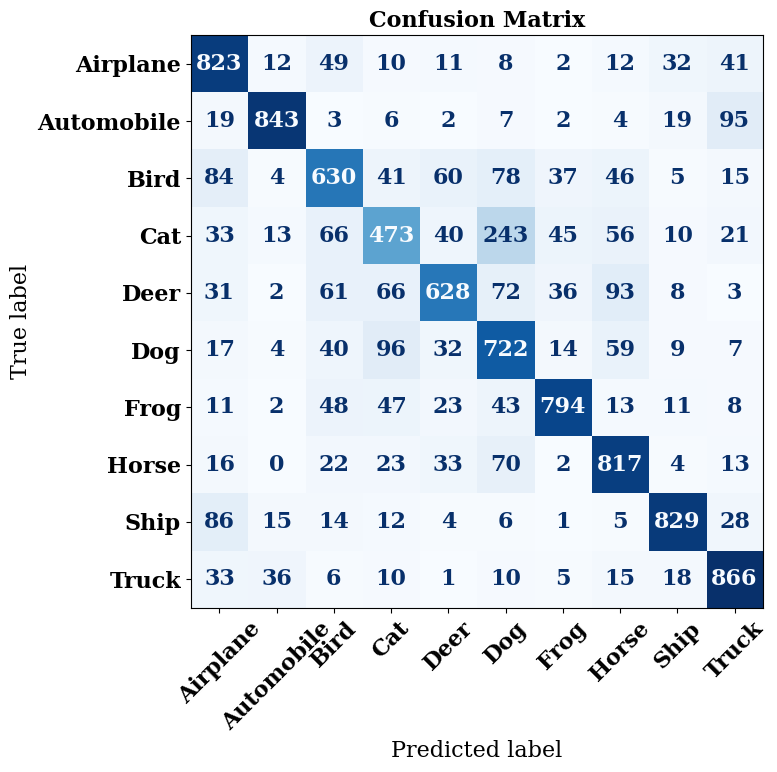

In [ ]:
# ==========================================================
# Block 19: Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 16

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues',
          ax=ax,
          colorbar=False)

plt.xticks(rotation=45,
           fontsize=16,
           fontweight='bold')

plt.yticks(fontsize=16,
           fontweight='bold')

plt.title("Confusion Matrix",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()

plt.savefig("Confusion_Matrix.eps",
            format='eps',
            dpi=600)

plt.show()

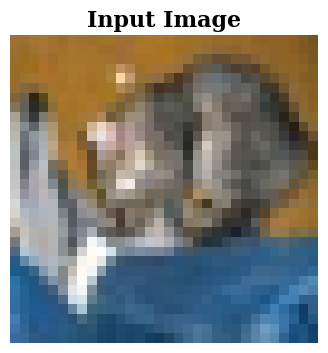

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


In [ ]:
# ==========================================================
# Block 20: Feature Map Visualization
# ==========================================================

# Select one image from the test set
image = X_test[0]

plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title("Input Image", fontsize=16, fontweight='bold')
plt.axis("off")
plt.savefig("Input_Image.eps", format="eps", dpi=600)
plt.show()

# Expand dimensions for prediction
image_batch = np.expand_dims(image, axis=0)

# Extract outputs of convolutional layers
conv_layers = []

for layer in model.layers:
    if isinstance(layer, Conv2D):
        conv_layers.append(layer.output)
feature_model = Model(
    inputs=model.inputs,
    outputs=conv_layers
)

feature_maps = feature_model.predict(image_batch)

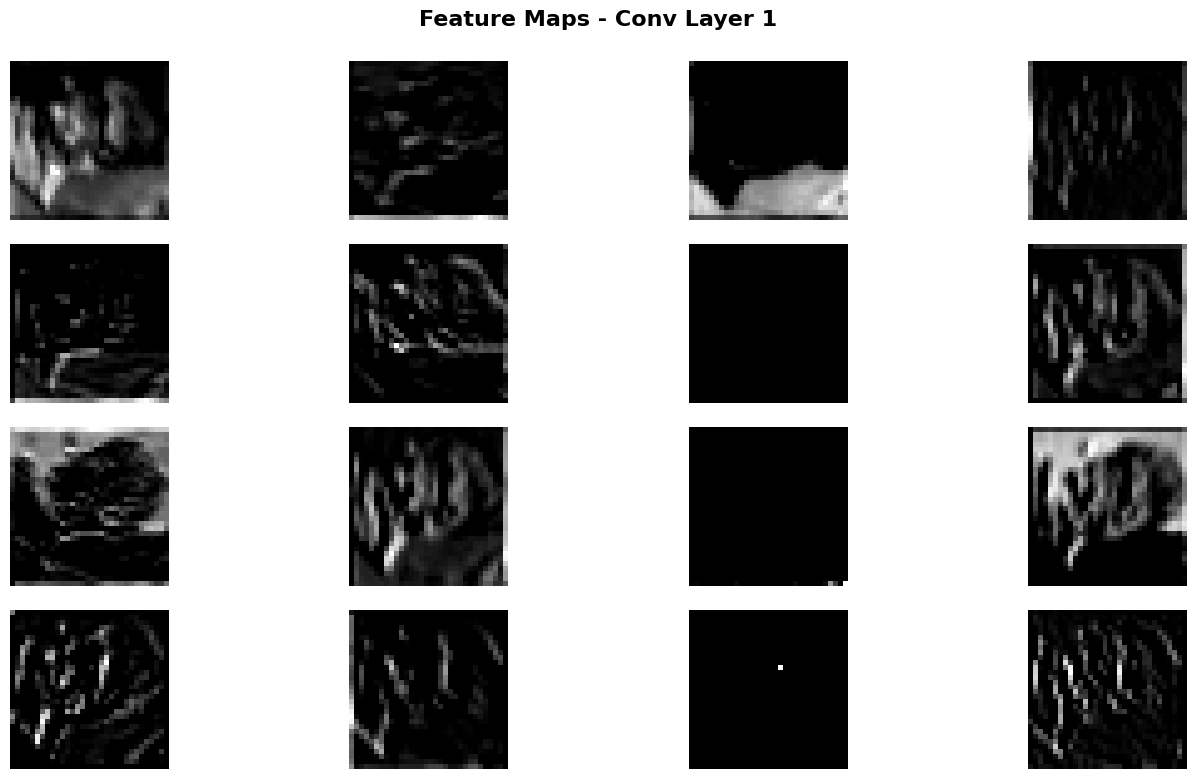

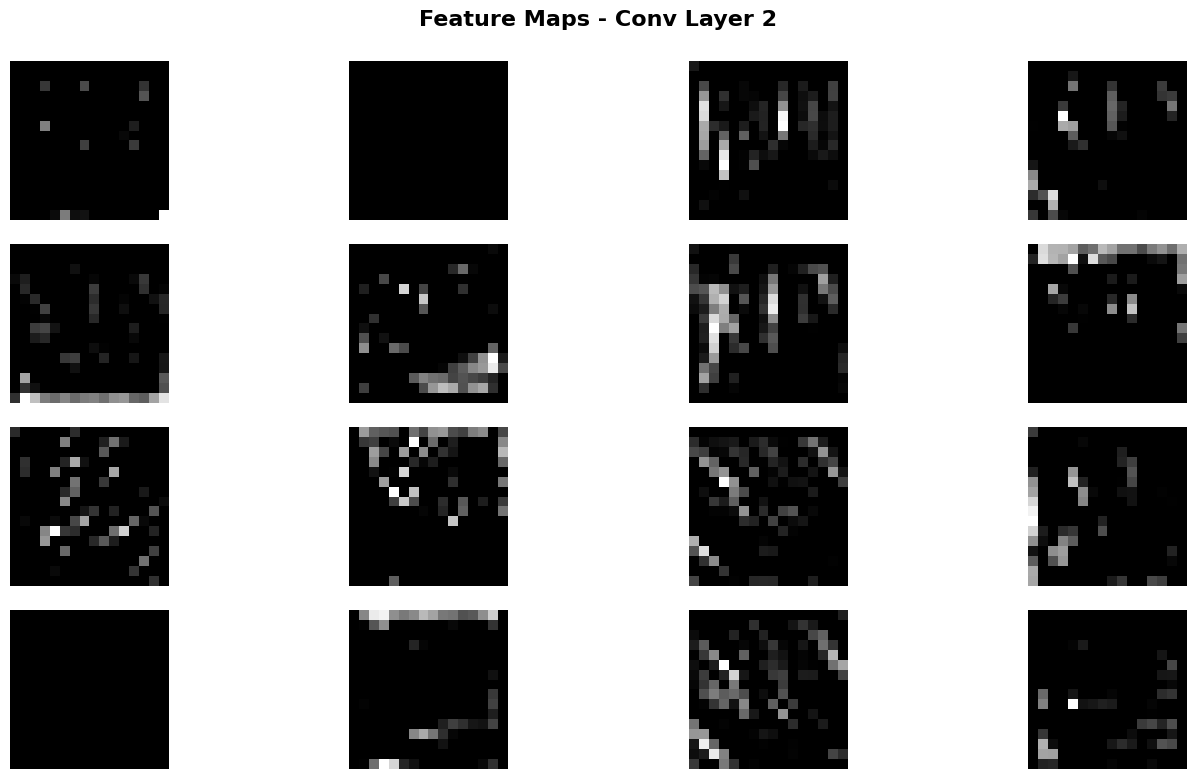

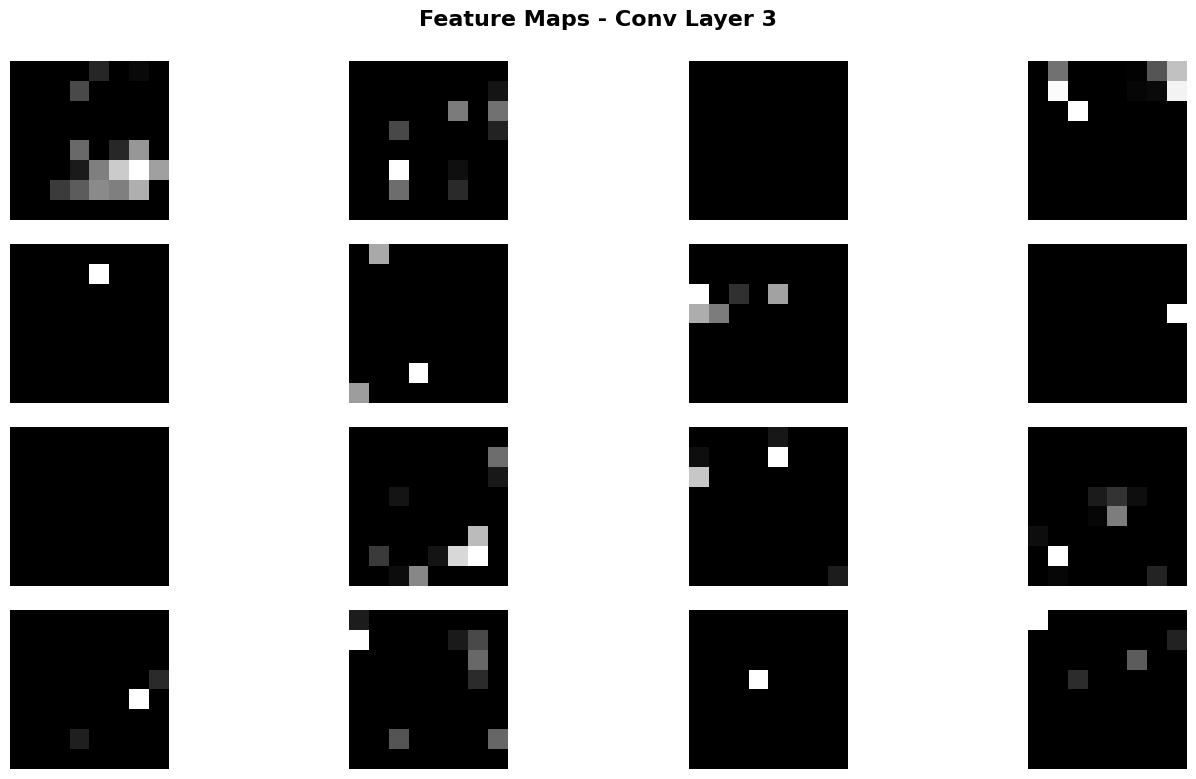

In [ ]:
# ==========================================================
# Block 21: Display Feature Maps
# ==========================================================

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 16

for layer_number, fmap in enumerate(feature_maps):

    plt.figure(figsize=(15,8))

    num_filters = min(16, fmap.shape[-1])

    for i in range(num_filters):

        plt.subplot(4,4,i+1)

        plt.imshow(fmap[0,:,:,i],
                   cmap='gray')

        plt.axis('off')

    plt.suptitle(f'Feature Maps - Conv Layer {layer_number+1}',
                 fontsize=16,
                 fontweight='bold')

    plt.tight_layout()

    plt.savefig(f"Feature_Map_Layer_{layer_number+1}.eps",
                format='eps',
                dpi=600)

    plt.show()

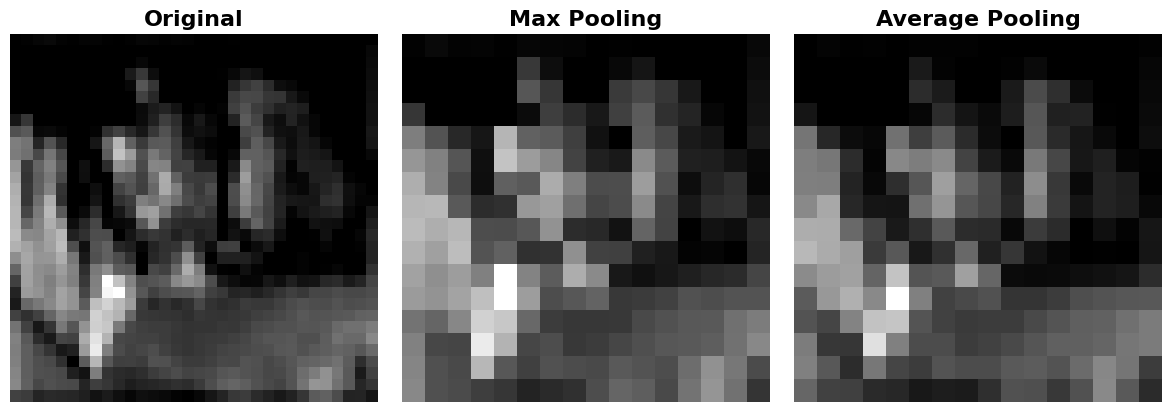

In [ ]:
# ==========================================================
# Block 22: Pooling Comparison
# ==========================================================

sample = feature_maps[0][0,:,:,0]

fig = plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(sample,cmap='gray')
plt.title("Original",
          fontsize=16,
          fontweight='bold')
plt.axis('off')

max_pool = tf.keras.layers.MaxPooling2D(pool_size=(2,2))
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(2,2))

sample_tensor = tf.expand_dims(sample,axis=0)
sample_tensor = tf.expand_dims(sample_tensor,-1)

max_result = max_pool(sample_tensor)
avg_result = avg_pool(sample_tensor)

plt.subplot(1,3,2)
plt.imshow(max_result.numpy()[0,:,:,0],
           cmap='gray')
plt.title("Max Pooling",
          fontsize=16,
          fontweight='bold')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(avg_result.numpy()[0,:,:,0],
           cmap='gray')
plt.title("Average Pooling",
          fontsize=16,
          fontweight='bold')
plt.axis('off')

plt.tight_layout()

plt.savefig("Pooling_Comparison.eps",
            format='eps',
            dpi=600)

plt.show()

In [ ]:
# ==========================================================
# Block 23: Hyperparameter Summary
# ==========================================================

import pandas as pd

hyperparameters = pd.DataFrame({

'Hyperparameter' : [

'Kernel Size',
'Filters',
'Stride',
'Padding',
'Pooling',
'Optimizer',
'Batch Size',
'Epochs'

],

'Value Used' : [

'3×3',

'32,64,128',

'1',

'Same',

'Max Pooling',

'Adam',

'64',

'20'

]

})

print(hyperparameters)

  Hyperparameter   Value Used
0    Kernel Size          3×3
1        Filters    32,64,128
2         Stride            1
3        Padding         Same
4        Pooling  Max Pooling
5      Optimizer         Adam
6     Batch Size           64
7         Epochs           20


In [ ]:
# ==========================================================
# Block 24: Hyperparameter Analysis Table
# ==========================================================

comparison = pd.DataFrame({

'Hyperparameter' : [

'Kernel Size',

'Number of Filters',

'Stride',

'Padding',

'Optimizer',

'Batch Size',

'Epochs'

],

'Observation' : [

'3×3 extracts detailed local features',

'More filters improve feature learning but increase computation',

'Stride = 1 preserves more spatial information',

'Same padding maintains image dimensions',

'Adam converges faster than SGD',

'64 provides a balance between speed and stability',

'20 epochs provide sufficient learning without severe overfitting'

]

})

comparison

,Hyperparameter,Observation
0,Kernel Size,3×3 extracts detailed local features
1,Number of Filters,More filters improve feature learning but incr...
2,Stride,Stride = 1 preserves more spatial information
3,Padding,Same padding maintains image dimensions
4,Optimizer,Adam converges faster than SGD
5,Batch Size,64 provides a balance between speed and stability
6,Epochs,20 epochs provide sufficient learning without ...


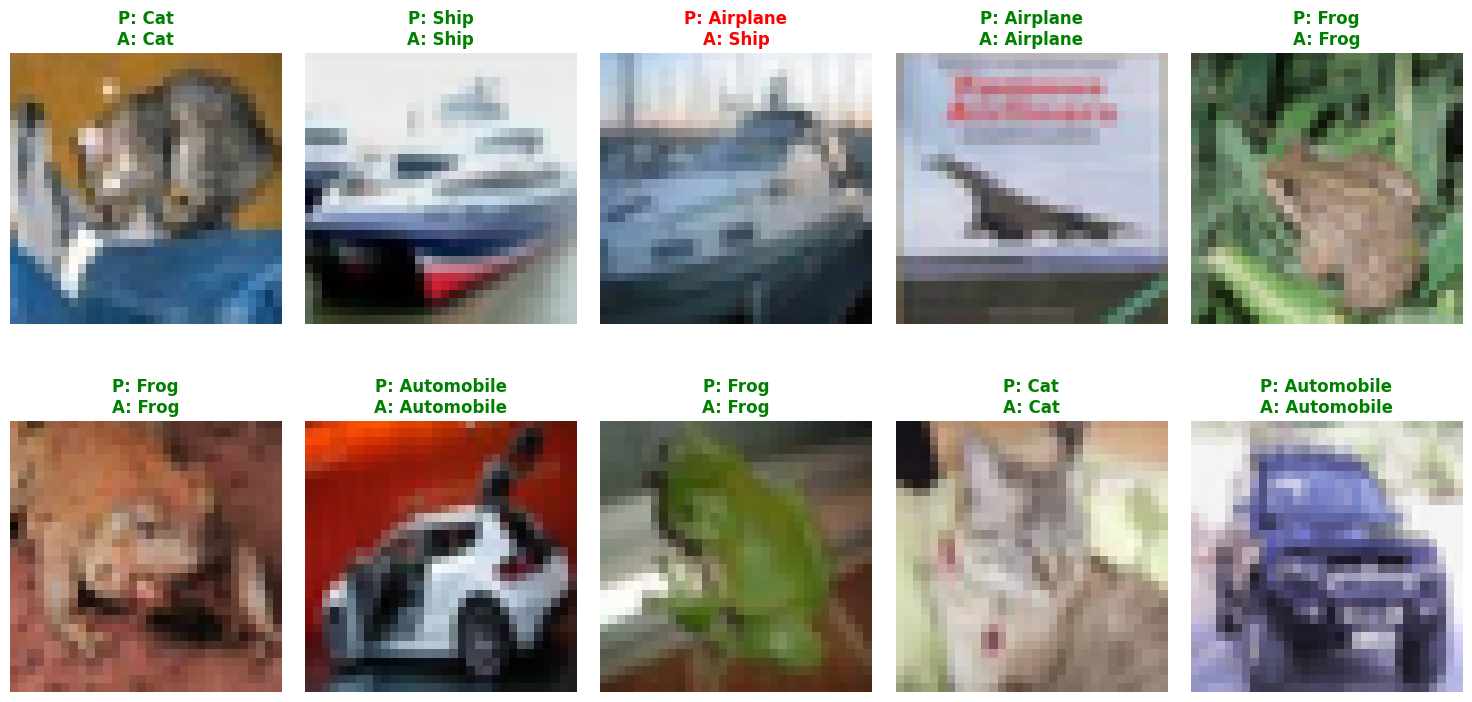

In [ ]:
# ==========================================================
# Block 25: Display Predictions
# ==========================================================

plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    pred = class_names[y_pred[i]]
    actual = class_names[y_true[i]]

    color = 'green' if pred == actual else 'red'

    plt.title(f"P: {pred}\nA: {actual}",
              fontsize=12,
              color=color,
              fontweight='bold')

    plt.axis('off')

plt.tight_layout()

plt.savefig("Predicted_Images.eps",
            format='eps',
            dpi=600)

plt.show()